In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd, numpy as np
import mlflow, mlflow.sklearn
from sklearn.metrics import accuracy_score


In [2]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
np.random.seed(42)
X['gender'] = np.random.randint(0, 2, size=len(X))

In [4]:
# Split (IMPORTANT)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Remove gender for training
X_train = X_train_full.drop(columns=['gender'])
X_test = X_test_full.drop(columns=['gender'])

In [5]:
'''
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Evaluate
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Save model
joblib.dump(model, "model.pkl")

print("✅ Model trained, evaluated, and saved")
'''

'\nmodel = RandomForestClassifier()\nmodel.fit(X_train, y_train)\n\n# Evaluate\ntrain_acc = model.score(X_train, y_train)\ntest_acc = model.score(X_test, y_test)\n\nprint("Train Accuracy:", train_acc)\nprint("Test Accuracy:", test_acc)\n\n# Save model\njoblib.dump(model, "model.pkl")\n\nprint("✅ Model trained, evaluated, and saved")\n'

In [13]:
# -------------------------------
# 3. MLflow setup
# -------------------------------
mlflow.set_tracking_uri("http://35.202.56.93:5000")  # your MLflow server
mlflow.set_experiment("iris_oppe2")

# -------------------------------
# 4. Train model
# -------------------------------
with mlflow.start_run():

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    # log metric
    mlflow.log_metric("accuracy", acc)

    # log model + register
    mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
        registered_model_name="iris_model"
    )

    print("Training complete. Accuracy:", acc)

joblib.dump(model, "model.pkl")

print("✅ Model trained, evaluated, and saved")

2026/05/01 19:17:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'iris_model' already exists. Creating a new version of this model...
2026/05/01 19:17:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: iris_model, version 2
Created version '2' of model 'iris_model'.


Training complete. Accuracy: 0.9
🏃 View run victorious-hare-717 at: http://35.202.56.93:5000/#/experiments/2/runs/54d44e105cbf4c6391539bb53bf882bb
🧪 View experiment at: http://35.202.56.93:5000/#/experiments/2
✅ Model trained, evaluated, and saved


Generating SHAP summary plot...


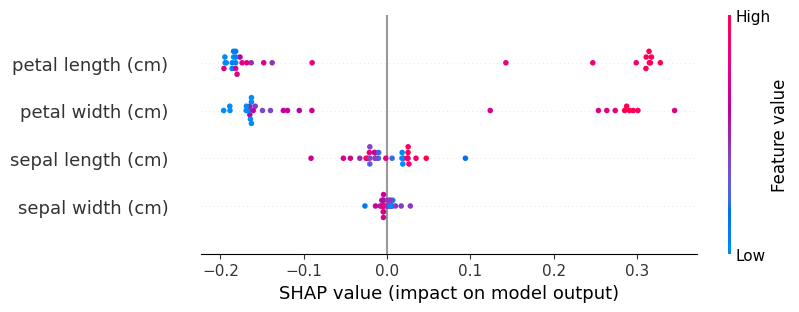

In [7]:
import shap

explainer = shap.Explainer(model, X_train)
#shap_values = explainer(X_test)
shap_values = explainer(X_test, check_additivity=False)
print("Generating SHAP summary plot...")
#shap.plots.beeswarm(shap_values[:, :, 2])   # Virginica class
shap.plots.beeswarm(shap_values[:, :, 2])
#shap.summary_plot(shap_values, X_test)

In [8]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, precision_score

preds_test = model.predict(X_test)

mf = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": lambda y_true, y_pred: precision_score(y_true, y_pred, average="macro")
    },
    y_true=y_test,
    y_pred=preds_test,
    sensitive_features=X_test_full['gender']
)

print(mf.by_group)

        accuracy  precision
gender                     
0       0.857143   0.888889
1       0.937500   0.916667


In [11]:
#y_poisoned = y_train.copy()

#n = int(0.1 * len(y_train))
#indices = np.random.choice(len(y_train), n, replace=False)
#y_poisoned[indices] = np.random.randint(0, 3, size=n)

y_poisoned = y_train.copy()

indices = np.random.choice(len(y_train), int(0.1 * len(y_train)), replace=False)

for i in indices:
    y_poisoned[i] = (y_poisoned[i] + 1) % 3

model_poisoned = RandomForestClassifier()
model_poisoned.fit(X_train, y_poisoned)

print("Clean Test Accuracy:", model.score(X_test, y_test))
print("Poisoned Test Accuracy:", model_poisoned.score(X_test, y_test))

Clean Test Accuracy: 0.9
Poisoned Test Accuracy: 0.9


In [10]:
X_drifted = X_test.copy()

X_drifted['petal length (cm)'] += 2

print("Train Mean:\n", X_train.mean())
print("Drifted Test Mean:\n", X_drifted.mean())

Train Mean:
 sepal length (cm)    5.841667
sepal width (cm)     3.048333
petal length (cm)    3.770000
petal width (cm)     1.205000
dtype: float64
Drifted Test Mean:
 sepal length (cm)    5.850000
sepal width (cm)     3.093333
petal length (cm)    5.710000
petal width (cm)     1.176667
dtype: float64


In [15]:
import requests
import json

for i in range(10):
    sample = X_train.sample(1).iloc[0]

    data = {
        "sepal_length": sample[0],
        "sepal_width": sample[1],
        "petal_length": sample[2],
        "petal_width": sample[3]
    }

    res = requests.post("http://35.202.56.93:8000/predict", json=data)

    print("Input:", data, "Prediction:", res.json())

Input: {'sepal_length': 5.1, 'sepal_width': 2.5, 'petal_length': 3.0, 'petal_width': 1.1} Prediction: {'prediction': 1}
Input: {'sepal_length': 6.4, 'sepal_width': 2.8, 'petal_length': 5.6, 'petal_width': 2.1} Prediction: {'prediction': 2}
Input: {'sepal_length': 5.8, 'sepal_width': 2.7, 'petal_length': 5.1, 'petal_width': 1.9} Prediction: {'prediction': 2}
Input: {'sepal_length': 7.6, 'sepal_width': 3.0, 'petal_length': 6.6, 'petal_width': 2.1} Prediction: {'prediction': 2}
Input: {'sepal_length': 6.0, 'sepal_width': 3.4, 'petal_length': 4.5, 'petal_width': 1.6} Prediction: {'prediction': 1}
Input: {'sepal_length': 4.9, 'sepal_width': 3.0, 'petal_length': 1.4, 'petal_width': 0.2} Prediction: {'prediction': 0}
Input: {'sepal_length': 5.8, 'sepal_width': 2.7, 'petal_length': 3.9, 'petal_width': 1.2} Prediction: {'prediction': 1}
Input: {'sepal_length': 5.8, 'sepal_width': 2.6, 'petal_length': 4.0, 'petal_width': 1.2} Prediction: {'prediction': 1}
Input: {'sepal_length': 5.6, 'sepal_widt

/var/tmp/ipykernel_5397/1802072274.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "sepal_length": sample[0],
/var/tmp/ipykernel_5397/1802072274.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "sepal_width": sample[1],
/var/tmp/ipykernel_5397/1802072274.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "petal_length": sample[2],
/var/tmp/ipykernel_5397/1802072274.py:11: FutureWarning: Series.__getitem__ treating keys as p